#Install Spatial Libraries

In [ ]:
!pip install geopandas libpysal esda mgwr spreg shapely

#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

from spreg import ML_Lag, ML_Error

#Load Data

In [ ]:
df = pd.read_csv("House Price India.csv")

#Pre-Processing For Spatial Analysis

##Remove Duplicates and Null Values

In [ ]:
df = df.drop_duplicates()
df = df.dropna(subset=["Lattitude","Longitude","Price"])

##Create Spatial DataFrame

In [ ]:
geometry = [Point(xy) for xy in zip(df["Longitude"], df["Lattitude"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

##Feature Engineering (Spatio-Temporal Variables)

In [ ]:
CURRENT_YEAR = 2026

gdf["price_log"] = np.log1p(gdf["Price"])
gdf["building_age"] = CURRENT_YEAR - gdf["Built Year"]
gdf["renovated"] = (gdf["Renovation Year"] > 0).astype(int)

gdf["accessibility_index"] = (
    gdf["Number of schools nearby"] /
    (gdf["Distance from the airport"] + 1)
)


##Create Spatial Weights (Neighborhood Structure)

In [ ]:
w = KNN.from_dataframe(gdf, k=6)
w.transform = 'R'

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


#GLOBAL SPATIAL AUTOCORRELATION

##Price Clustering

In [ ]:
moran_price = Moran(gdf["price_log"], w)
print("Moran’s I (Price):", moran_price.I)
print("p-value:", moran_price.p_sim)

Moran’s I (Price): 0.7209537322276515
p-value: 0.001


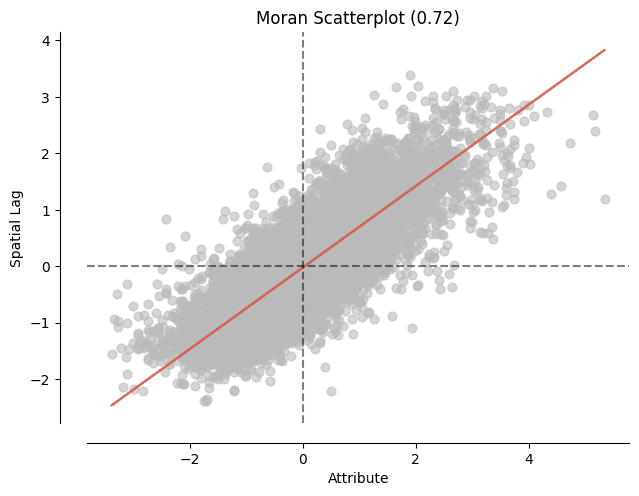

In [ ]:
from esda.moran import Moran
from splot.esda import moran_scatterplot

moran_scatterplot(moran_price)
plt.show()

##Building Age Clustering

In [ ]:
moran_age = Moran(gdf["building_age"], w)
print("Moran’s I (Age):", moran_age.I)
print("p-value:", moran_age.p_sim)

Moran’s I (Age): 0.4946416930334664
p-value: 0.001


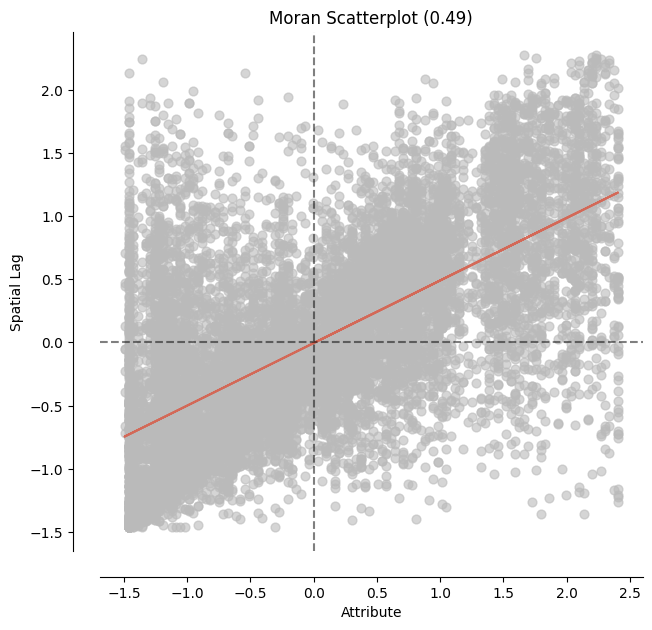

In [ ]:
from esda.moran import Moran
from splot.esda import moran_scatterplot

moran_scatterplot(moran_age)
plt.show()

##Accessibility Clustering

In [ ]:
moran_access = Moran(gdf["accessibility_index"], w)
print("Moran’s I (Accessibility):", moran_access.I)
print("p-value:", moran_access.p_sim)

Moran’s I (Accessibility): -0.004252238607038289
p-value: 0.152


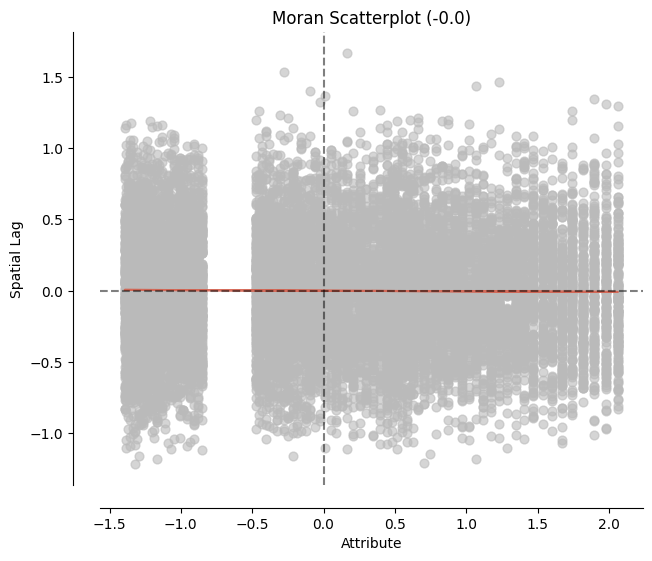

In [ ]:
from esda.moran import Moran
from splot.esda import moran_scatterplot

moran_scatterplot(moran_access)
plt.show()

#LOCAL SPATIAL AUTOCORRELATION (LISA)

In [ ]:
lisa = Moran_Local(gdf["price_log"], w)

gdf["LISA_cluster"] = lisa.q
gdf["LISA_significant"] = lisa.p_sim < 0.05

#Spatial Clustering Using LISA

In [ ]:
cluster_counts = gdf[gdf["LISA_significant"]]["LISA_cluster"].value_counts()

print("Significant LISA Cluster Counts:")
print(cluster_counts)

Significant LISA Cluster Counts:
LISA_cluster
3    3566
1    2724
4     135
2      66
Name: count, dtype: int64


In [ ]:
cluster_labels = {
    1: "High-High (Luxury Hotspot)",
    2: "Low-Low (Affordable Cluster)",
    3: "High-Low (Isolated Expensive)",
    4: "Low-High (Emerging Area)"
}

gdf["LISA_label"] = gdf["LISA_cluster"].map(cluster_labels)


<Figure size 800x600 with 0 Axes>

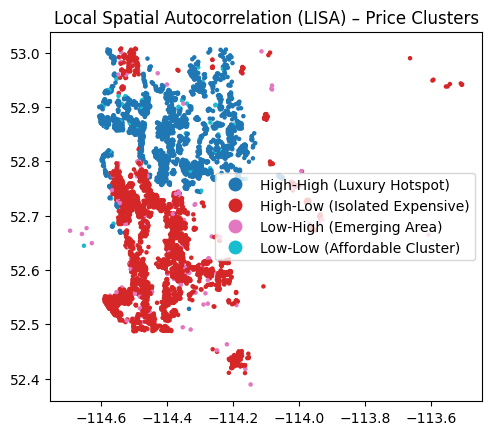

In [ ]:
import matplotlib.pyplot as plt

significant = gdf[gdf["LISA_significant"] == True]

plt.figure(figsize=(8,6))
significant.plot(
    column="LISA_label",
    categorical=True,
    legend=True,
    markersize=5
)

plt.title("Local Spatial Autocorrelation (LISA) – Price Clusters")
plt.show()


#Spatial Clustering using K-Means

##Silhouette Score for Optimal Clusters

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(scaled)
    score = silhouette_score(scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")


K=2, Silhouette Score=0.289
K=3, Silhouette Score=0.309
K=4, Silhouette Score=0.311
K=5, Silhouette Score=0.279
K=6, Silhouette Score=0.258
K=7, Silhouette Score=0.228
K=8, Silhouette Score=0.255
K=9, Silhouette Score=0.253


##Clustering (Market Segementation based on Location, price_log and living area)

###N_Clusters = 4

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use spatial + economic features
features = gdf[["Longitude","Lattitude","price_log","living area"]]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
gdf["market_cluster"] = kmeans.fit_predict(scaled)

print(gdf["market_cluster"].value_counts())

market_cluster
2    5290
0    4119
3    2931
1    2279
Name: count, dtype: int64


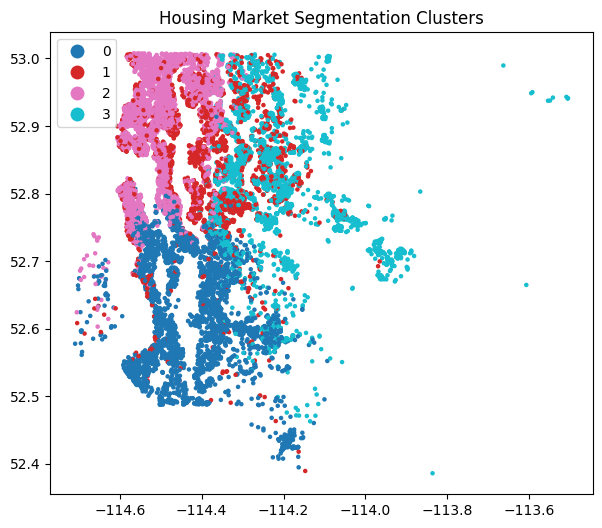

In [ ]:
import matplotlib.pyplot as plt
gdf.plot(
    column="market_cluster",
    categorical=True,
    legend=True,
    figsize=(8,6),
    markersize=5
)

plt.title("Housing Market Segmentation Clusters")
plt.show()


###N_Clusters = 3

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use spatial + economic features
features = gdf[["Longitude","Lattitude","price_log","living area"]]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
gdf["market_cluster"] = kmeans.fit_predict(scaled)

print(gdf["market_cluster"].value_counts())

market_cluster
2    6055
0    4623
1    3941
Name: count, dtype: int64


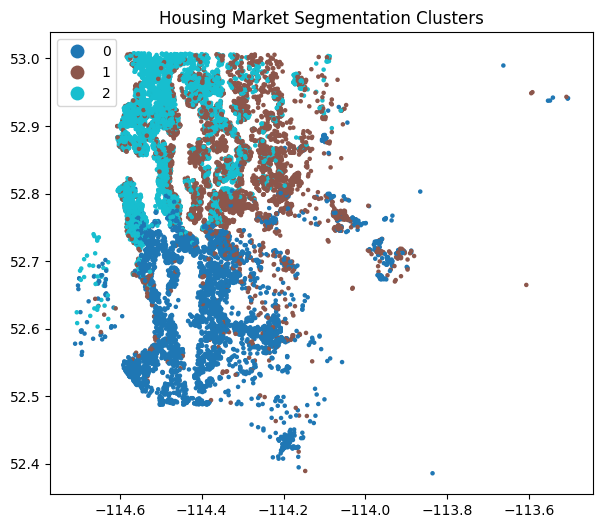

In [ ]:
import matplotlib.pyplot as plt
gdf.plot(
    column="market_cluster",
    categorical=True,
    legend=True,
    figsize=(8,6),
    markersize=5
)

plt.title("Housing Market Segmentation Clusters")
plt.show()

#SPATIAL HETEROGENEITY And Stationarity — GWR MODEL

##OlS

In [ ]:
import statsmodels.api as sm

X = gdf[[
    "living area",
    "number of bedrooms",
    "grade of the house",
    "building_age",
    "accessibility_index"
]]

X = sm.add_constant(X)

y = gdf["price_log"]

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              price_log   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     5076.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:08:41   Log-Likelihood:                -3985.0
No. Observations:               14619   AIC:                             7982.
Df Residuals:                   14613   BIC:                             8027.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  10.4681    

##GWR

In [ ]:
coords = np.array(list(zip(gdf["Longitude"], gdf["Lattitude"])))

X = gdf[[
    "living area",
    "number of bedrooms",
    "grade of the house",
    "building_age",
    "accessibility_index"
]].values

y = gdf["price_log"].values.reshape((-1,1))

bw = Sel_BW(coords, y, X).search()

gwr_model = GWR(coords, y, X, bw)
gwr_results = gwr_model.fit()

print(gwr_results.summary())

Model type                                                         Gaussian
Number of observations:                                               14619
Number of covariates:                                                     6

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           1476.419
Log-likelihood:                                                   -3984.952
AIC:                                                               7981.903
AICc:                                                              7983.911
BIC:                                                            -138663.381
R2:                                                                   0.635
Adj. R2:                                                              0.634

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

###Coefficient Variability

In [ ]:
import pandas as pd

coef_variation = pd.DataFrame({
    "Variable": ["Living Area", "Bedrooms", "Grade", "Building Age", "Accessibility"],
    "Std Dev": gwr_results.params[:,1:].std(axis=0)
})

print(coef_variation)

        Variable   Std Dev
0    Living Area  0.000070
1       Bedrooms  0.043211
2          Grade  0.053789
3   Building Age  0.002892
4  Accessibility  1.667597


In [ ]:
#The substantial improvement of GWR over the global OLS model (AIC reduced from ~7982 to ~-9753 and R² increased from 0.63 to 0.90) indicates that the relationship between housing characteristics and price varies across space.

#Additionally, the spatial variability of coefficients, particularly the large standard deviation observed for the accessibility variable, confirms the presence of spatial non-stationarity. This suggests that locational advantages influence property values differently across regions, justifying the use of local spatial models rather than a single global regression.


#Trend Analysis

##Construction Trend

In [ ]:
gdf["construction_decade"] = (gdf["Built Year"] // 10) * 10

trend_price = gdf.groupby("construction_decade")["Price"].mean()

print(trend_price)

construction_decade
1900    643159.671840
1910    598353.680529
1920    588081.609524
1930    589423.310992
1940    446175.383193
1950    473143.721519
1960    449928.759153
1970    494804.052283
1980    530432.283079
1990    586594.527415
2000    609271.939547
2010    628082.712740
Name: Price, dtype: float64


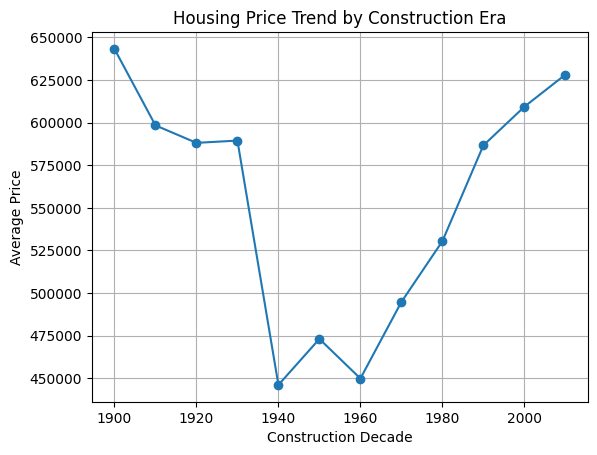

In [ ]:
import matplotlib.pyplot as plt

trend_price.plot(marker='o')
plt.xlabel("Construction Decade")
plt.ylabel("Average Price")
plt.title("Housing Price Trend by Construction Era")
plt.grid(True)
plt.show()

In [ ]:
#Note: The observed trend does not represent historical house prices.
#Since the dataset is cross-sectional, the analysis reflects how properties built in different development eras are valued in the present market. Higher values for early construction periods likely indicate location-driven land appreciation rather than temporal price inflation.


##Renovation Trend

In [ ]:
renov_trend = gdf[gdf["Renovation Year"] > 0].groupby("Renovation Year")["Price"].mean()

print(renov_trend.tail())

Renovation Year
2011    653131.818182
2012    674222.222222
2013    613508.333333
2014    660405.263158
2015    637666.666667
Name: Price, dtype: float64


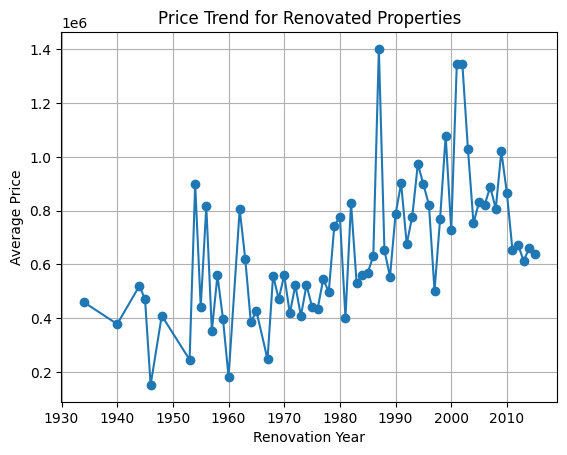

In [ ]:
renov_trend.plot(marker='o')
plt.xlabel("Renovation Year")
plt.ylabel("Average Price")
plt.title("Price Trend for Renovated Properties")
plt.grid(True)
plt.show()

##Spatial Trend Gradient

In [ ]:
from scipy.stats import pearsonr

corr_lat, _ = pearsonr(gdf["Lattitude"], gdf["Built Year"])
corr_lon, _ = pearsonr(gdf["Longitude"], gdf["Built Year"])

print("Trend Expansion Latitude:", corr_lat)
print("Trend Expansion Longitude:", corr_lon)

Trend Expansion Latitude: -0.1431080711109084
Trend Expansion Longitude: 0.41452336107266663


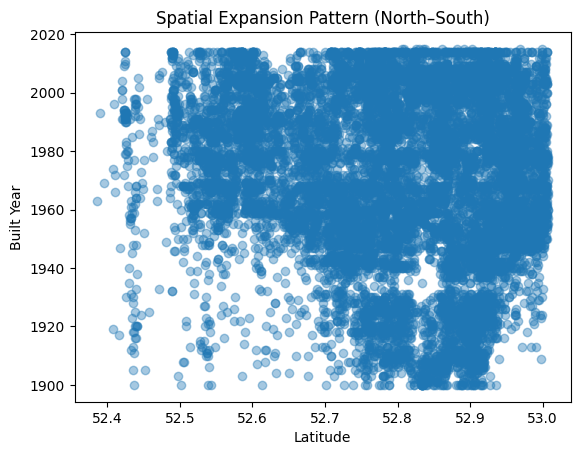

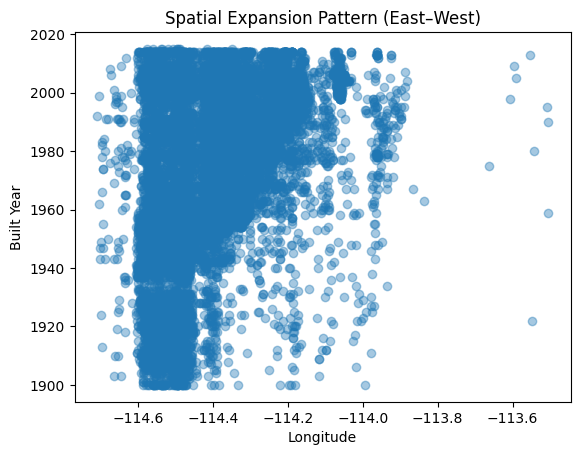

In [ ]:
plt.scatter(gdf["Lattitude"], gdf["Built Year"], alpha=0.4)
plt.xlabel("Latitude")
plt.ylabel("Built Year")
plt.title("Spatial Expansion Pattern (North–South)")
plt.show()

plt.scatter(gdf["Longitude"], gdf["Built Year"], alpha=0.4)
plt.xlabel("Longitude")
plt.ylabel("Built Year")
plt.title("Spatial Expansion Pattern (East–West)")
plt.show()

#SPATIAL HOLDOUT VALIDATION

##Train-Test Split

In [ ]:
median_lat = gdf["Lattitude"].median()

train = gdf[gdf["Lattitude"] <= median_lat]
test  = gdf[gdf["Lattitude"] > median_lat]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 7311
Test size: 7308


##Spatial weights For Train

In [ ]:
from libpysal.weights import KNN

w_train = KNN.from_dataframe(train, k=6)
w_train.transform = 'R'

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


##X_Train and X_Test and Y_Train

In [ ]:
X_train = train[[
    "living area",
    "number of bedrooms",
    "grade of the house",
    "building_age",
    "accessibility_index"
]].values

X_test = test[[
    "living area",
    "number of bedrooms",
    "grade of the house",
    "building_age",
    "accessibility_index"
]].values

In [ ]:
y_train = np.log1p(train["Price"]).values.reshape((-1,1))

#Spatial Regression Models

##Spatial Lag Model

###Train

In [ ]:
from spreg import ML_Lag

lag_train = ML_Lag(y_train, X_train, w=w_train)
print(lag_train.summary)

/usr/local/lib/python3.12/dist-packages/spreg/ml_lag.py:710: RuntimeWarning: divide by zero encountered in log
  jacob = np.log(np.linalg.det(a))


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:        7311
Mean dependent var  :     12.8151                Number of Variables   :           7
S.D. dependent var  :      0.4935                Degrees of Freedom    :        7304
Pseudo R-squared    :      0.8198
Spatial Pseudo R-squared:  0.6552
Log likelihood      :    832.8931
Sigma-square ML     :      0.0439                Akaike info criterion :   -1651.786
S.E of regression   :      0.2096                Schwarz criterion     :   -1603.506

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------------------------------------------

###Predict on Test Data

In [ ]:
beta = lag_train.betas.flatten()

intercept = beta[0]
rho = beta[-1]                 # spatial lag coefficient
beta_features = beta[1:-1]     # only feature coefficients

# Predict using feature part only
y_pred = intercept + X_test @ beta_features

test["predicted_log_price"] = y_pred
test["predicted_price"] = np.expm1(y_pred)

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


###Accuracy Measure

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(test["Price"], test["predicted_price"]))
mae  = mean_absolute_error(test["Price"], test["predicted_price"])

print("Spatial Holdout RMSE:", rmse)
print("Spatial Holdout MAE:", mae)

Spatial Holdout RMSE: 771402.2404591349
Spatial Holdout MAE: 655331.2085599939


##Spatial Error Model

###Train

In [ ]:
#Train and Test data same as used for Spatial Lag Model
from spreg import ML_Error

error_model = ML_Error(y_train, X_train, w=w_train)
print(error_model.summary)

/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
---------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:        7311
Mean dependent var  :     12.8151                Number of Variables   :           6
S.D. dependent var  :      0.4935                Degrees of Freedom    :        7305
Pseudo R-squared    :      0.6252
Log likelihood      :   1287.1866
Sigma-square ML     :      0.0355                Akaike info criterion :   -2562.373
S.E of regression   :      0.1884                Schwarz criterion     :   -2520.990

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        11.49907    

###Predict on test Data

In [ ]:
betas_err = error_model.betas.flatten()

intercept_err = betas_err[0]
lambda_param = betas_err[-1]          # spatial error parameter (not used in prediction)
beta_features_err = betas_err[1:-1]   # ONLY feature coefficients

# Predict using feature part
y_pred_err = intercept_err + X_test @ beta_features_err

test["pred_price_error"] = np.expm1(y_pred_err)

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


###Accuracy Measure

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_err = np.sqrt(mean_squared_error(test["Price"], test["pred_price_error"]))
mae_err = mean_absolute_error(test["Price"], test["pred_price_error"])

print("Error Model RMSE:", rmse_err)
print("Error Model MAE:", mae_err)

Error Model RMSE: 357887.87095230795
Error Model MAE: 231521.16265262483


##Simple OLS Regression (For Comparision to Spatial Models)

###Train

In [ ]:
import statsmodels.api as sm

X_train_ols = sm.add_constant(X_train)
ols_holdout = sm.OLS(y_train, X_train_ols).fit()

###Predict on Test Data

In [ ]:
X_test_ols = sm.add_constant(X_test)
y_pred_ols = ols_holdout.predict(X_test_ols)

test["pred_price_ols"] = np.expm1(y_pred_ols)

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


###Accuracy Measure

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_ols = np.sqrt(mean_squared_error(test["Price"], test["pred_price_ols"]))
mae_ols  = mean_absolute_error(test["Price"], test["pred_price_ols"])

print("OLS RMSE:", rmse_ols)
print("OLS MAE:", mae_ols)

OLS RMSE: 373482.9677609869
OLS MAE: 209783.26246381772
